In [ ]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
energy = pd.read_csv(r'D:\energy\PV\cleaned_data\apu_energy.csv');
energy.head()

,Log Type,System,TimeStamp,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
0,APU Energy,APU 1,2025-10-01 00:00:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2599,1287273.0,826.2931,451749.4,1054.821,412543.7,95.27699,306165.9,47.69901,47539.22
1,APU Energy,APU 1,2025-10-01 00:01:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2609,1287273.0,826.2931,451749.4,1054.821,412543.7,95.27699,306165.9,47.69901,47539.22
2,APU Energy,APU 1,2025-10-01 00:02:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2609,1287273.0,826.2931,451749.4,1054.822,412543.7,95.27699,306165.9,47.69901,47539.22
3,APU Energy,APU 1,2025-10-01 00:03:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2609,1287273.0,826.2941,451749.4,1054.822,412543.7,95.27699,306165.9,47.69901,47539.22
4,APU Energy,APU 1,2025-10-01 00:04:00,1636615.0,414112.7,1576228,4161159.0,1593088,4099188.0,1426159,...,730.2619,1287273.0,826.2941,451749.4,1054.823,412543.7,95.27699,306165.9,47.69901,47539.22


In [3]:
energy.duplicated().sum()

np.int64(74)

In [19]:
energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 149984 entries, 0 to 149983
Data columns (total 27 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Log Type      149984 non-null  str    
 1   System        149984 non-null  str    
 2   TimeStamp     149984 non-null  str    
 3   CH 1 pos/Ah   149984 non-null  float64
 4   CH 1 neg/Ah   149984 non-null  float64
 5   CH 2 pos/Ah   149984 non-null  int64  
 6   CH 2 neg/Ah   149984 non-null  float64
 7   CH 3 pos/Ah   149984 non-null  int64  
 8   CH 3 neg/Ah   149984 non-null  float64
 9   CH 4 pos/Ah   149984 non-null  int64  
 10  CH 4 neg/Ah   149984 non-null  float64
 11  CH 5 pos/Ah   149984 non-null  int64  
 12  CH 5 neg/Ah   149984 non-null  float64
 13  CH 6 pos/Ah   149984 non-null  int64  
 14  CH 6 neg/Ah   149984 non-null  float64
 15  CH 7 pos/Ah   149984 non-null  float64
 16  CH 7 neg/Ah   149984 non-null  float64
 17  CH 8 pos/Ah   149984 non-null  float64
 18  CH 8 neg/Ah   1

In [4]:
energy.columns

Index(['Log Type', 'System', 'TimeStamp', 'CH 1 pos/Ah', 'CH 1 neg/Ah',
       'CH 2 pos/Ah', 'CH 2 neg/Ah', 'CH 3 pos/Ah', 'CH 3 neg/Ah',
       'CH 4 pos/Ah', 'CH 4 neg/Ah', 'CH 5 pos/Ah', 'CH 5 neg/Ah',
       'CH 6 pos/Ah', 'CH 6 neg/Ah', 'CH 7 pos/Ah', 'CH 7 neg/Ah',
       'CH 8 pos/Ah', 'CH 8 neg/Ah', 'CH 9 pos/Ah', 'CH 9 neg/Ah',
       'CH 10 pos/Ah', 'CH 10 neg/Ah', 'CH 11 pos/Ah', 'CH 11 neg/Ah',
       'CH 12 pos/Ah', 'CH 12 neg/Ah'],
      dtype='str')

In [5]:
energy_new = energy.drop_duplicates().reset_index(drop=True)

In [6]:
energy_new.duplicated().sum()

np.int64(0)

In [7]:
energy_new.describe()

,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,CH 4 neg/Ah,CH 5 pos/Ah,CH 5 neg/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
count,1.499100e+05,149910.000000,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,1.499100e+05,...,149910.000000,1.499100e+05,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000,149910.000000
mean,8.371375e+05,416631.294838,1.470814e+06,1.531216e+06,1.586983e+06,1.493394e+06,1.601524e+06,2.267974e+06,1.605684e+06,2.006387e+06,...,906.168423,8.819038e+05,478.240128,374788.713711,578.162437,211586.558347,664.118076,311220.948217,510.739026,197443.555547
std,8.360586e+05,35858.195923,1.650202e+05,1.542192e+06,9.594083e+04,1.550650e+06,1.032287e+05,1.406549e+06,4.779714e+04,1.327350e+06,...,138.533369,2.921875e+05,379.410696,55434.748422,531.982567,179266.468506,551.084598,15283.485450,471.715194,155110.675564
min,9.856730e+02,356514.000000,1.277444e+06,4.549537e+05,1.415760e+06,1.925564e+05,1.426159e+06,7.272034e+05,1.537467e+06,8.639413e+05,...,730.259900,4.778257e+05,92.362000,297983.300000,41.070990,31418.070000,95.276990,287776.700000,47.699010,39830.220000
25%,1.157057e+03,359787.700000,1.291290e+06,4.667554e+05,1.475868e+06,2.768670e+05,1.582251e+06,1.085237e+06,1.563203e+06,8.710851e+05,...,833.624900,4.833643e+05,96.470250,300870.800000,44.433242,32445.007500,132.997000,306165.900000,49.534000,47539.220000
50%,1.651724e+03,429407.450000,1.343990e+06,7.453562e+05,1.632482e+06,8.332093e+05,1.675655e+06,1.088184e+06,1.625656e+06,1.519592e+06,...,931.402400,8.112528e+05,106.270000,363067.500000,53.486000,34910.710000,1142.974000,313821.700000,830.261100,318093.500000
75%,1.655375e+06,445986.325000,1.594074e+06,1.004414e+06,1.650109e+06,1.142349e+06,1.688712e+06,3.855015e+06,1.656054e+06,3.614312e+06,...,1103.941750,9.488104e+05,838.137100,385255.400000,1069.991000,366920.800000,1266.476750,326702.975000,1101.044000,365249.000000
max,1.707763e+06,451435.500000,1.685953e+06,4.194862e+06,1.684279e+06,4.129589e+06,1.699717e+06,4.125131e+06,1.674789e+06,4.136527e+06,...,1119.072000,1.302365e+06,888.188100,457129.200000,1163.632000,416386.900000,1283.939000,333451.900000,1116.254000,383566.900000


In [8]:
energy_apu1 = energy_new.loc[(energy_new['System'] == 'APU 1')]


In [20]:
energy_apu1.info()

<class 'pandas.DataFrame'>
RangeIndex: 37476 entries, 0 to 37475
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Log Type      37476 non-null  str    
 1   System        37476 non-null  str    
 2   TimeStamp     37476 non-null  str    
 3   CH 1 pos/Ah   37476 non-null  float64
 4   CH 1 neg/Ah   37476 non-null  float64
 5   CH 2 pos/Ah   37476 non-null  int64  
 6   CH 2 neg/Ah   37476 non-null  float64
 7   CH 3 pos/Ah   37476 non-null  int64  
 8   CH 3 neg/Ah   37476 non-null  float64
 9   CH 4 pos/Ah   37476 non-null  int64  
 10  CH 4 neg/Ah   37476 non-null  float64
 11  CH 5 pos/Ah   37476 non-null  int64  
 12  CH 5 neg/Ah   37476 non-null  float64
 13  CH 6 pos/Ah   37476 non-null  int64  
 14  CH 6 neg/Ah   37476 non-null  float64
 15  CH 7 pos/Ah   37476 non-null  float64
 16  CH 7 neg/Ah   37476 non-null  float64
 17  CH 8 pos/Ah   37476 non-null  float64
 18  CH 8 neg/Ah   37476 non-null  float64

In [17]:
metadata_df = energy_apu1.iloc[:, :3]
numeric_df = energy_apu1.loc[:, 'CH 1 pos/Ah':].astype(float).diff()
energy_apu1_perminute = pd.concat([metadata_df, numeric_df], axis=1).dropna()

In [24]:
energy_apu1_perminute

,Log Type,System,TimeStamp,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
1,APU Energy,APU 1,2025-10-01 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0
2,APU Energy,APU 1,2025-10-01 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.000,0.0,0.001,0.0,0.000,0.0,0.0,0.0
3,APU Energy,APU 1,2025-10-01 00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.001,0.0,0.000,0.0,0.000,0.0,0.0,0.0
4,APU Energy,APU 1,2025-10-01 00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001,0.0,0.000,0.0,0.001,0.0,0.000,0.0,0.0,0.0
5,APU Energy,APU 1,2025-10-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37471,APU Energy,APU 1,2025-10-27 09:05:00,2.0,0.0,3.0,0.0,3.0,0.0,4.0,...,0.000,0.0,0.001,1.9,0.001,0.0,0.000,0.0,0.0,0.0
37472,APU Energy,APU 1,2025-10-27 09:06:00,2.0,0.0,1.0,0.0,2.0,0.0,2.0,...,0.001,0.0,0.000,17.5,0.000,0.0,0.000,0.0,0.0,0.0
37473,APU Energy,APU 1,2025-10-27 09:07:00,3.0,0.0,3.0,7.0,3.0,0.0,3.0,...,0.000,0.0,0.001,0.0,0.000,0.0,0.001,0.0,0.0,0.0
37474,APU Energy,APU 1,2025-10-27 09:08:00,2.0,0.0,2.0,100.0,2.0,0.0,2.0,...,0.000,0.0,0.000,0.0,0.001,0.0,0.000,0.0,0.0,0.0


In [22]:
energy_apu1_perminute.describe()

,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,CH 4 neg/Ah,CH 5 pos/Ah,CH 5 neg/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
count,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,...,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000,37475.000000
mean,0.500627,0.110850,0.476237,0.899346,0.486751,0.811234,0.516664,0.499106,0.508873,0.197953,...,0.000282,0.402722,0.000316,0.143557,0.000405,0.102554,0.000037,0.081265,0.000018,0.014035
std,0.841001,1.416759,0.829256,9.312224,0.838959,8.030228,0.874471,5.176814,0.864611,2.312201,...,0.000668,5.333801,0.000728,1.849474,0.000872,1.570841,0.000197,1.222613,0.000137,0.192117
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.001000,0.000000,0.001000,0.000000,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,110.300000,4.000000,447.000000,4.000000,268.000000,4.000000,270.000000,4.000000,115.100000,...,0.096000,419.000000,0.109000,90.500000,0.140000,164.500000,0.012000,119.600000,0.006000,20.150000


In [18]:
energy_apu1_perminute.info()

<class 'pandas.DataFrame'>
RangeIndex: 37475 entries, 1 to 37475
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Log Type      37475 non-null  str    
 1   System        37475 non-null  str    
 2   TimeStamp     37475 non-null  str    
 3   CH 1 pos/Ah   37475 non-null  float64
 4   CH 1 neg/Ah   37475 non-null  float64
 5   CH 2 pos/Ah   37475 non-null  float64
 6   CH 2 neg/Ah   37475 non-null  float64
 7   CH 3 pos/Ah   37475 non-null  float64
 8   CH 3 neg/Ah   37475 non-null  float64
 9   CH 4 pos/Ah   37475 non-null  float64
 10  CH 4 neg/Ah   37475 non-null  float64
 11  CH 5 pos/Ah   37475 non-null  float64
 12  CH 5 neg/Ah   37475 non-null  float64
 13  CH 6 pos/Ah   37475 non-null  float64
 14  CH 6 neg/Ah   37475 non-null  float64
 15  CH 7 pos/Ah   37475 non-null  float64
 16  CH 7 neg/Ah   37475 non-null  float64
 17  CH 8 pos/Ah   37475 non-null  float64
 18  CH 8 neg/Ah   37475 non-null  float64

In [21]:
#energy_apu1_perminute.loc[:, 'CH 1 pos/Ah':] = energy_apu1_perminute.loc[:, 'CH 1 pos/Ah':].diff()
# loi xung dot du lieu

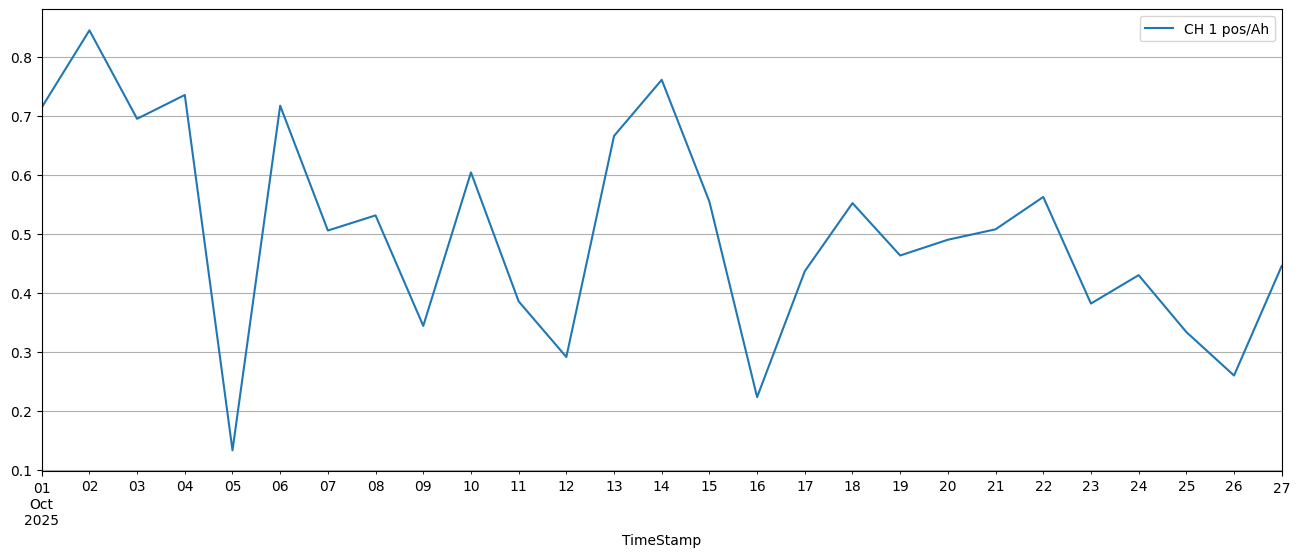

In [25]:
apu1 = energy_apu1_perminute.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
apu1['TimeStamp'] = pd.to_datetime(apu1['TimeStamp'])
apu1.set_index('TimeStamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['CH 1 pos/Ah']
apu1[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(350,400)
plt.show()


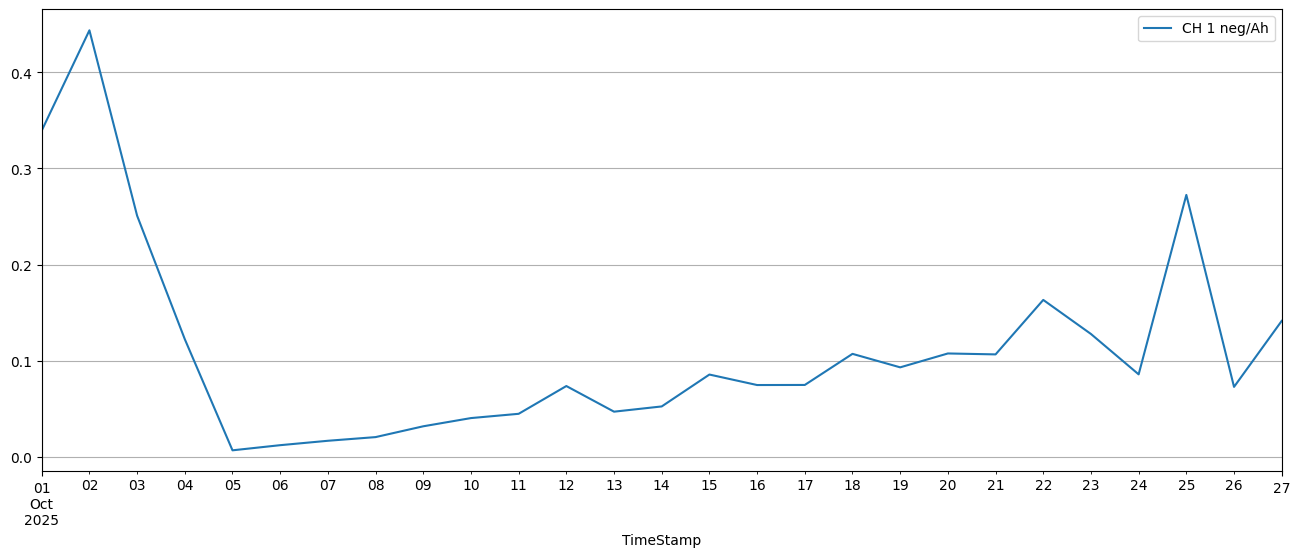

In [27]:
# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['CH 1 neg/Ah']
apu1[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(350,400)
plt.show()


Dung lượng dòng điện thấp nhất vào ngày 5/10
Xem xét ngày 4,5,6/ 10

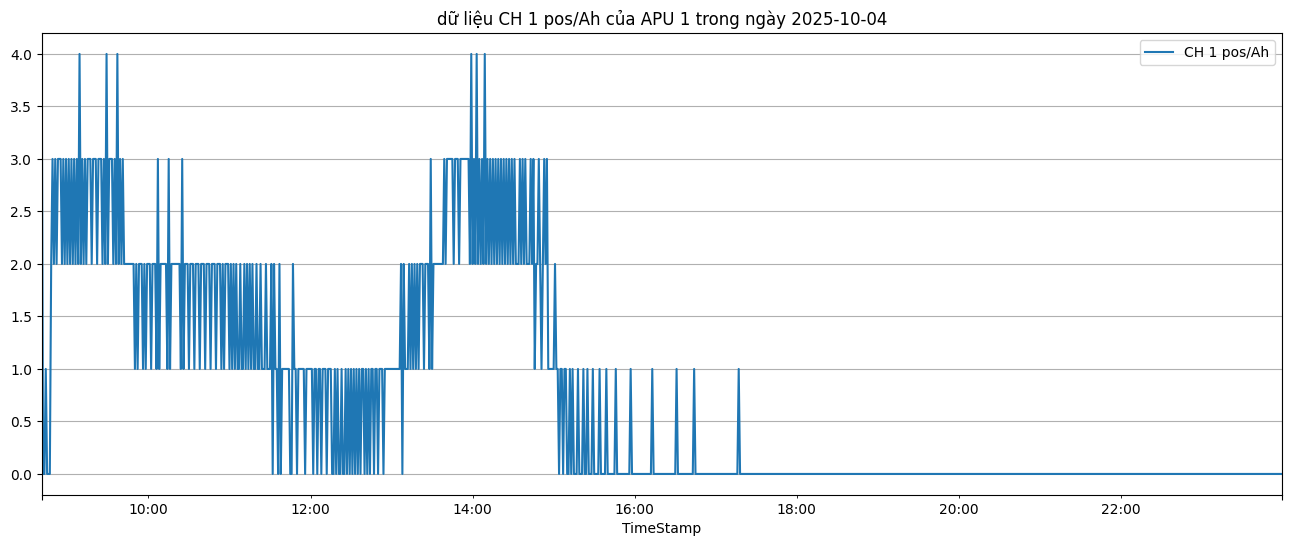

In [29]:
energy_s0410 = energy_apu1_perminute[energy_apu1_perminute['TimeStamp'].str.startswith('2025-10-04')]
s0410 = energy_s0410.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s0410['TimeStamp'] = pd.to_datetime(s0410['TimeStamp'])
s0410.set_index('TimeStamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['CH 1 pos/Ah']
s0410[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu CH 1 pos/Ah của APU 1 trong ngày 2025-10-04")
#plt.ylim(300,390)
plt.show()


Mất dữ liệu trong khoagr 8-10h ngày 4/10

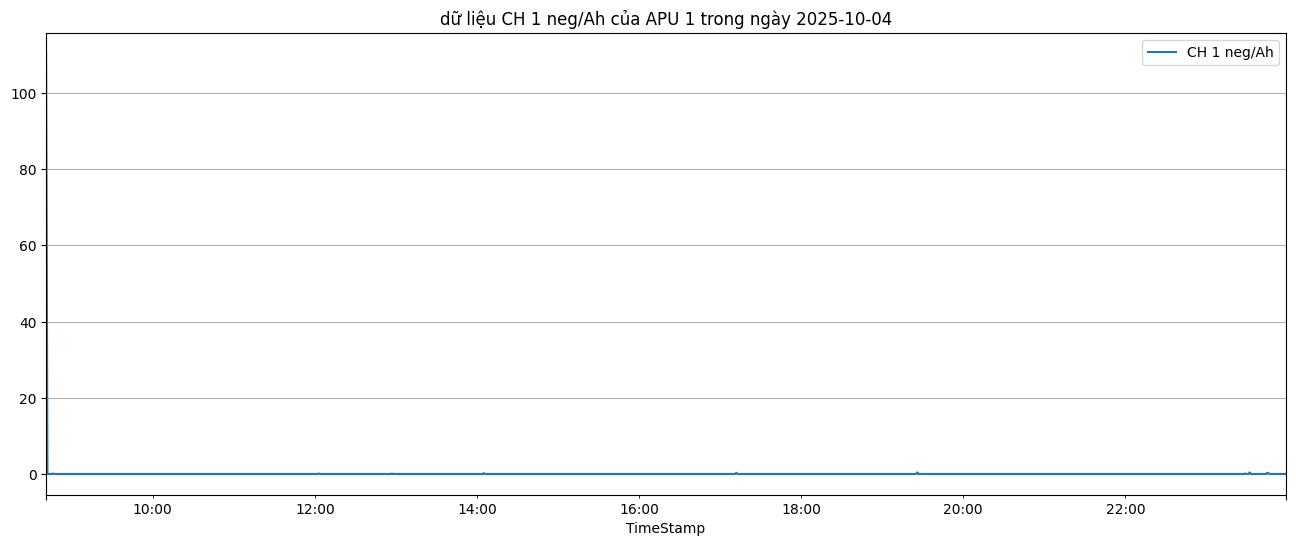

In [33]:
cols_to_plot = ['CH 1 neg/Ah']
s0410[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu CH 1 neg/Ah của APU 1 trong ngày 2025-10-04")
#plt.ylim(300,390)
plt.show()


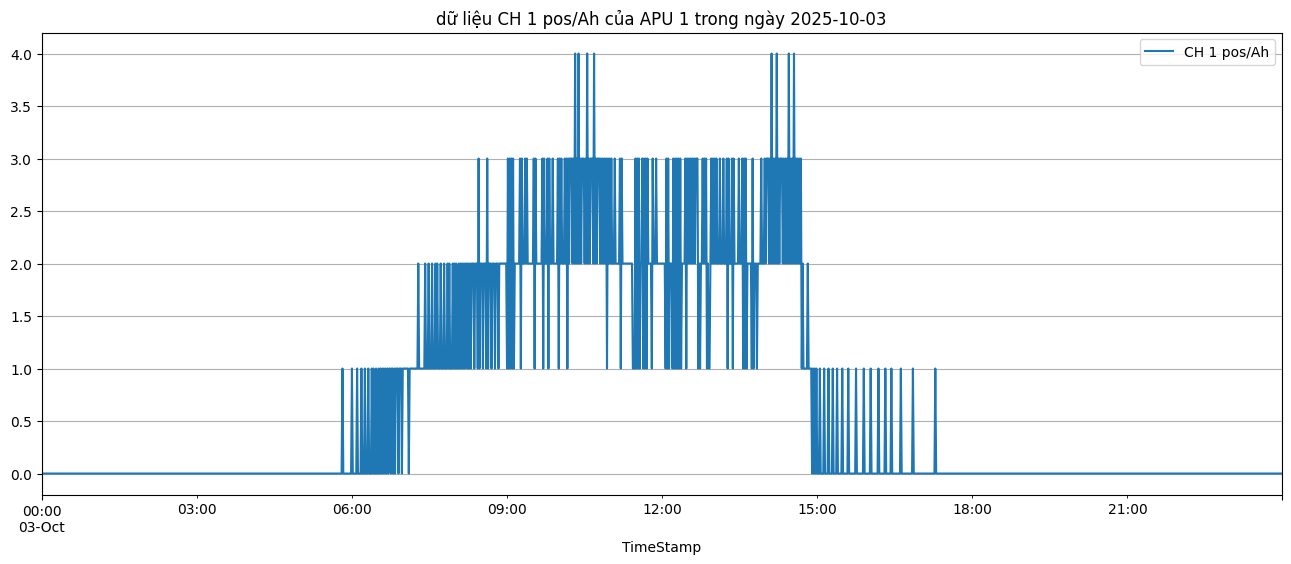

In [30]:
energy_s0310 = energy_apu1_perminute[energy_apu1_perminute['TimeStamp'].str.startswith('2025-10-03')]
s0310 = energy_s0310.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s0310['TimeStamp'] = pd.to_datetime(s0310['TimeStamp'])
s0310.set_index('TimeStamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['CH 1 pos/Ah']
s0310[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu CH 1 pos/Ah của APU 1 trong ngày 2025-10-03")
#plt.ylim(300,390)
plt.show()


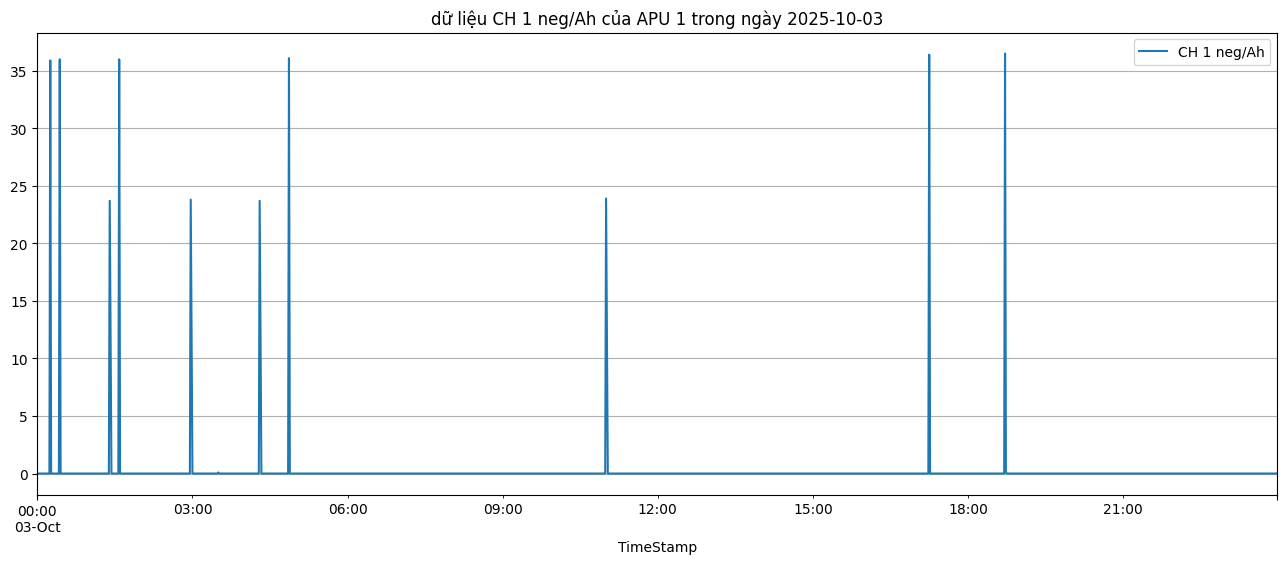

In [31]:
cols_to_plot = ['CH 1 neg/Ah']
s0310[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu CH 1 neg/Ah của APU 1 trong ngày 2025-10-03")
#plt.ylim(300,390)
plt.show()


pos phản ánh dòng điện theo chiều thuâtnj (chièu nạp vào)  
neg phản ánh dòng điện theo chiều âm, nguyên nhân có thể do đóng ngắt thiết bị  (tải cao đột ngột)

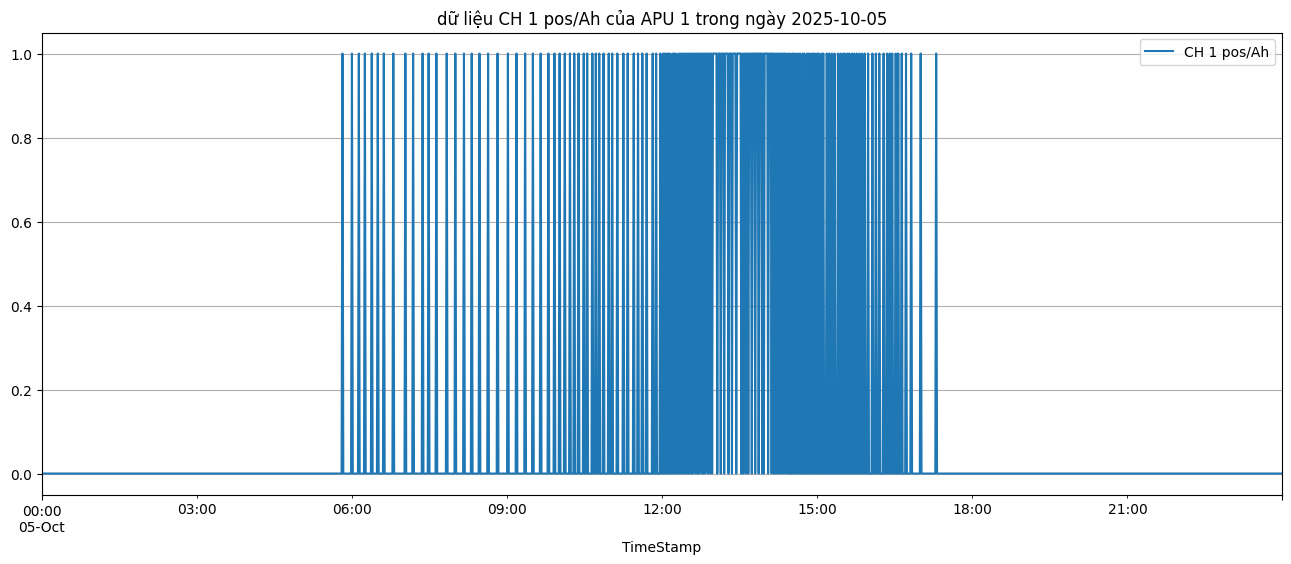

In [34]:
energy_s0510 = energy_apu1_perminute[energy_apu1_perminute['TimeStamp'].str.startswith('2025-10-05')]
s0510 = energy_s0510.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s0510['TimeStamp'] = pd.to_datetime(s0510['TimeStamp'])
s0510.set_index('TimeStamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['CH 1 pos/Ah']
s0510[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu CH 1 pos/Ah của APU 1 trong ngày 2025-10-05")
#plt.ylim(300,390)
plt.show()


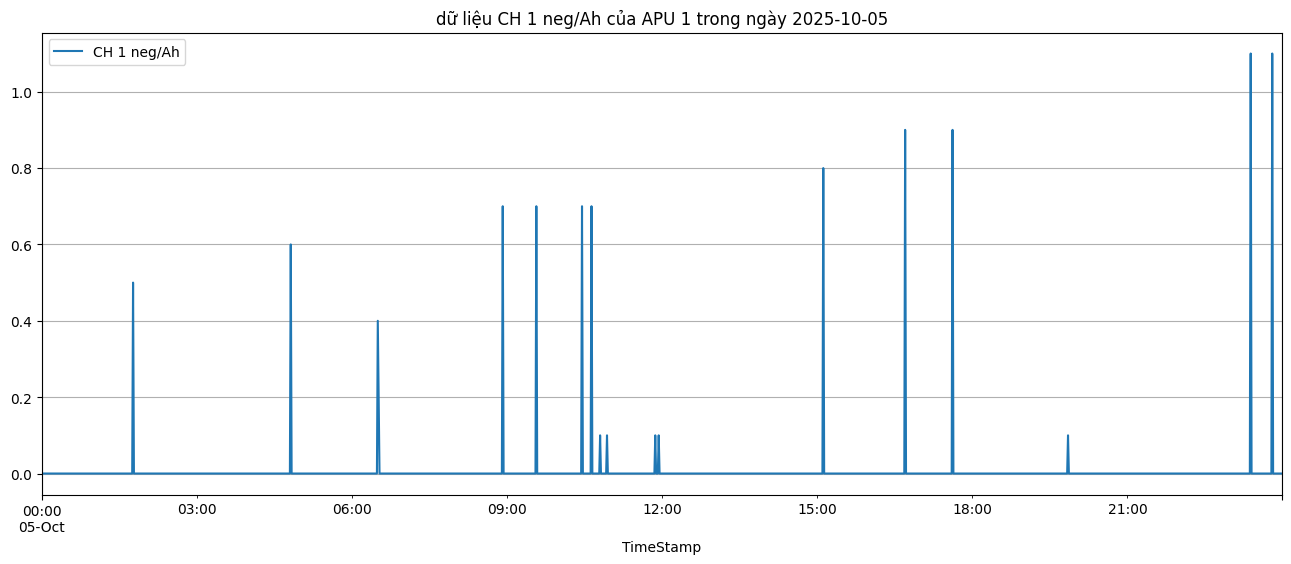

In [35]:
cols_to_plot = ['CH 1 neg/Ah']
s0510[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu CH 1 neg/Ah của APU 1 trong ngày 2025-10-05")
#plt.ylim(300,390)
plt.show()


In [32]:
energy_s0310

,Log Type,System,TimeStamp,CH 1 pos/Ah,CH 1 neg/Ah,CH 2 pos/Ah,CH 2 neg/Ah,CH 3 pos/Ah,CH 3 neg/Ah,CH 4 pos/Ah,...,CH 8 pos/Ah,CH 8 neg/Ah,CH 9 pos/Ah,CH 9 neg/Ah,CH 10 pos/Ah,CH 10 neg/Ah,CH 11 pos/Ah,CH 11 neg/Ah,CH 12 pos/Ah,CH 12 neg/Ah
2881,APU Energy,APU 1,2025-10-03 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2882,APU Energy,APU 1,2025-10-03 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2883,APU Energy,APU 1,2025-10-03 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.001,0.0,0.001,0.0,0.0,0.0,0.0,0.0
2884,APU Energy,APU 1,2025-10-03 00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2885,APU Energy,APU 1,2025-10-03 00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001,0.0,0.000,0.0,0.001,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4316,APU Energy,APU 1,2025-10-03 23:55:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0
4317,APU Energy,APU 1,2025-10-03 23:56:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0
4318,APU Energy,APU 1,2025-10-03 23:57:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000,0.0,0.001,0.0,0.001,0.0,0.0,0.0,0.0,0.0
4319,APU Energy,APU 1,2025-10-03 23:58:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0


Nhận xét  
Mất dữ liệu ngày 4/10, trong khoảng thời gian từ 0h - 8h